In [1]:
import mglearn
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('single_variable_data.csv')

In [31]:
health_risk_columns = ['risk_depression', 'risk_drug', 'risk_iadl', 'risk_health', 'risk_age'] #A
# infra_gap 
# aging_rate 
economic_instability_columns = ['risk_housing_tenure', 'risk_unemployed', 'risk_subj_econ'] #D
living_conditions_columns = ['risk_housing_safety', 'risk_housing_env'] #E
social_activities_columns = ['risk_group', 'risk_digital', 'risk_meet'] #F
self_care_deficit_columns = ['risk_nutrition', 'risk_smoke', 'risk_alcohol']  #G
despair_columns = ['risk_suicide', 'risk_network'] #H

In [32]:
pca_A = PCA(n_components=1)

pca_D = PCA(n_components=1)
pca_E = PCA(n_components=1)
pca_F = PCA(n_components=1)
pca_G = PCA(n_components=1)
pca_H = PCA(n_components=1)

In [33]:
PC1_health_risk = pca_A.fit_transform(df[health_risk_columns])
PC1_health_risk

array([[-0.28416233],
       [ 0.21340292],
       [-0.04350728],
       ...,
       [-0.32097565],
       [-0.16571908],
       [-0.28346389]], shape=(3448, 1))

In [54]:

PC1_economic_instability = pca_D.fit_transform(df[economic_instability_columns])
PC1_living_conditions = pca_E.fit_transform(df[living_conditions_columns])
PC1_social_activities = pca_F.fit_transform(df[social_activities_columns])
PC1_self_care_deficit = pca_G.fit_transform(df[self_care_deficit_columns])
PC1_despair = pca_H.fit_transform(df[despair_columns])

In [55]:
health_risk = pd.DataFrame(PC1_health_risk, columns = ['health_risk'])

economic_instability = pd.DataFrame(PC1_economic_instability, columns = ['economic_instability'])
living_conditions = pd.DataFrame(PC1_living_conditions, columns = ['living_conditions'])
social_activities = pd.DataFrame(PC1_social_activities, columns = ['social_activities'])
self_care_deficit = pd.DataFrame(PC1_self_care_deficit, columns = ['self_care_deficit'])
despair = pd.DataFrame(PC1_despair, columns = ['despair'])

In [56]:
economic_instability.head()

,economic_instability
0,0.320258
1,0.518918
2,-0.620617
3,0.320258
4,0.518918


In [57]:
PCA_weighted_df = pd.concat(
    [health_risk, df[['risk_infra_gap']], df[['risk_aging_rate']], economic_instability, living_conditions, social_activities, self_care_deficit, despair],
    axis=1
)
PCA_weighted_df.head()

,health_risk,risk_infra_gap,risk_aging_rate,economic_instability,living_conditions,social_activities,self_care_deficit,despair
0,-0.284162,0.621723,0.310723,0.320258,-0.398979,-0.577289,0.150994,-0.027290
1,0.213403,0.621723,0.310723,0.518918,0.246012,0.217422,-0.845627,0.139247
2,-0.043507,0.621723,0.310723,-0.620617,0.157215,-0.465505,-0.916249,-0.027290
3,-0.058321,0.621723,0.310723,0.320258,-0.048431,0.216420,-0.845627,-0.027290
4,0.657564,0.621723,0.310723,0.518918,0.187587,0.544167,0.171966,-0.360365


In [58]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [59]:
inertia_kmeans = []
sil_scores_kmeans = []
K_range = range(2,14)

for n_clusters in K_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    # n_init: initial centroid 변경횟수 
    # 없이 했다가 추가하니까 실루엣스코어 살짝씩 올랐음
    cluster_labels = kmeans.fit_predict(PCA_weighted_df)
    
    inertia_kmeans.append(kmeans.inertia_)
    sil_scores_kmeans.append(silhouette_score(PCA_weighted_df, cluster_labels))

In [60]:
inertia_kmeans 

[2239.6959526748633,
 1741.3502549073382,
 1427.1381900959796,
 1247.6453106210852,
 1129.198499665313,
 1040.0316495231966,
 984.9351533372135,
 916.4712500227745,
 872.308521647541,
 821.0075451727967,
 788.3469746123723,
 742.4570467820358]

In [61]:
sil_scores_kmeans

[0.2851872254043678,
 0.2990216781923736,
 0.34573898632271943,
 0.35427896056121794,
 0.37273930911220193,
 0.3187622665716222,
 0.3163546567812554,
 0.3285179101301546,
 0.3014271269954139,
 0.30676271179578973,
 0.2734486912464381,
 0.27857375458766637]

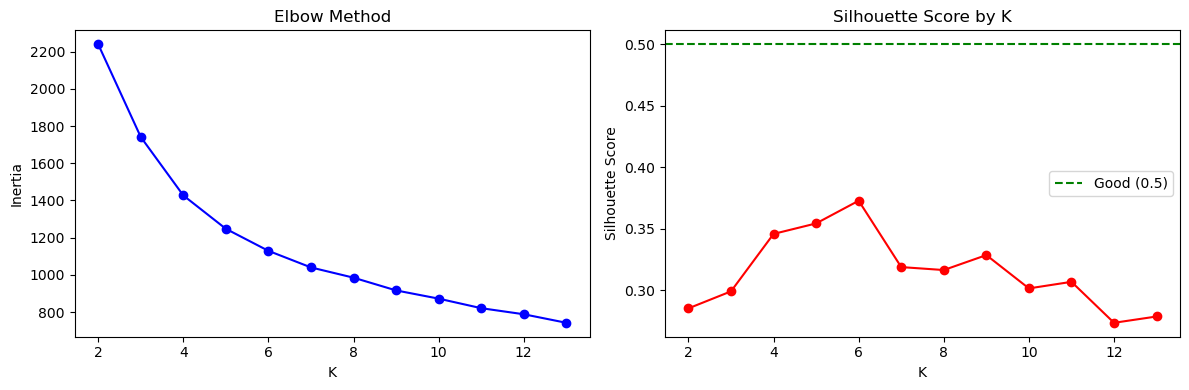

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertia_kmeans, 'bo-')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, sil_scores_kmeans, 'ro-')
axes[1].axhline(y=0.5, color='g', linestyle='--', label='Good (0.5)')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
axes[1].legend()
plt.tight_layout()
plt.show()

In [44]:
# 가중치 제곱합은 1
weightsA = pca_A.components_[0]  # shape: (4,)
weightsA

array([0.62057674, 0.29637522, 0.19989728, 0.61591702, 0.32822788])

In [63]:
weightD = pca_D.components_[0]
weightE = pca_E.components_[0]
weightF = pca_F.components_[0]
weightG = pca_G.components_[0]
weightH = pca_H.components_[0]
print(weightD)
print(weightE)
print(weightF)
print(weightG)
print(weightH)

[0.15547753 0.98405687 0.08636443]
[0.93479486 0.35518808]
[ 0.16684115  0.98264408 -0.0810842 ]
[ 0.04194424 -0.07062179  0.99662091]
[0.03935896 0.99922514]


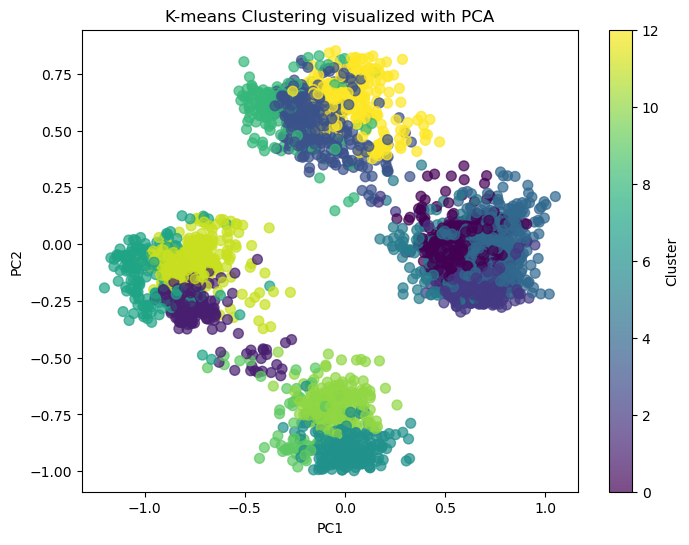

In [66]:
kmeans_k6 = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels_k6 = kmeans.fit_predict(PCA_weighted_df)

pca_vis_2d = PCA(n_components=2)
X_pca_2d = pca_vis_2d.fit_transform(PCA_weighted_df)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=cluster_labels_k6, cmap='viridis', s=50, alpha=0.7)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means Clustering visualized with PCA')
plt.colorbar(scatter, label='Cluster')
plt.show()

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

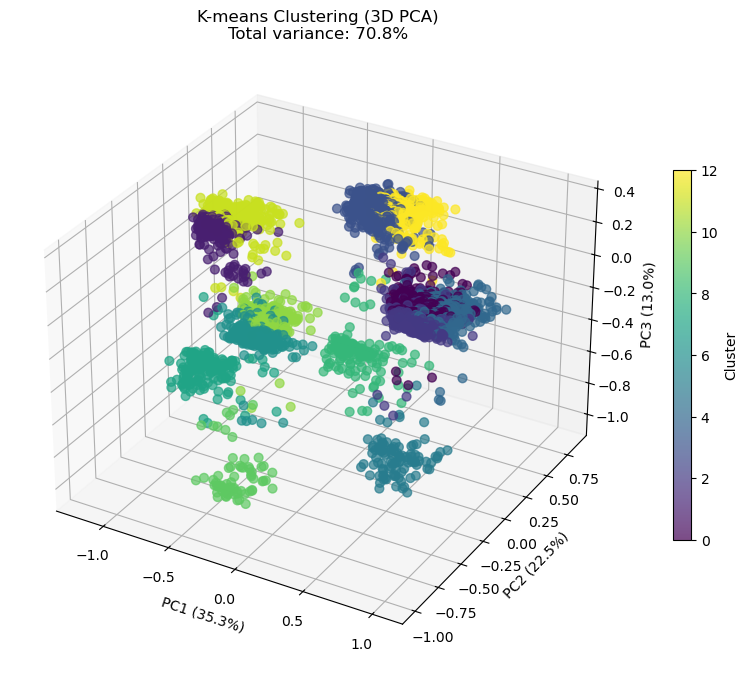

In [68]:
pca_vis_3d = PCA(n_components=3)
X_pca_3d = pca_vis_3d.fit_transform(PCA_weighted_df)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
                     c=cluster_labels_k6, cmap='viridis', s=40, alpha=0.7)

ax.set_xlabel(f'PC1 ({pca_vis_3d.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_vis_3d.explained_variance_ratio_[1]:.1%})')
ax.set_zlabel(f'PC3 ({pca_vis_3d.explained_variance_ratio_[2]:.1%})')
ax.set_title(f'K-means Clustering (3D PCA)\nTotal variance: {sum(pca_vis_3d.explained_variance_ratio_):.1%}')

plt.colorbar(scatter, label='Cluster', shrink=0.6)
plt.show()

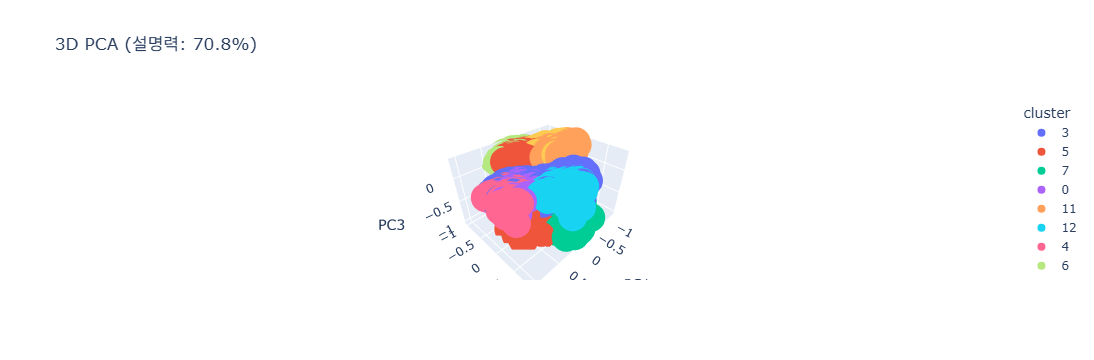

In [69]:
import plotly.express as px

df_00 = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_00['cluster'] = cluster_labels_k6.astype(str)

fig = px.scatter_3d(df_00, x='PC1', y='PC2', z='PC3', color='cluster',
                    title=f'3D PCA (설명력: {sum(pca_vis_3d.explained_variance_ratio_):.1%})')
fig.show()

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_kmeans, cmap='tab10')
plt.title('t-SNE: 더 정확한 클러스터 시각화')
plt.show()
# t-SNE는 6개로 잘 보일 가능성 높음